# CA-3 | Predicting Customer Purchase Intentions
### Online Shoppers Purchasing Intention Dataset — UCI Machine Learning Repository
**Student:** Leticia Andrade Vieira | **ID:** 2025304  
**Module:** Strategic Thinking | **Lecturer:** Taufique Ahmed  
**Framework:** CRISP-DM

---

#### Imports libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

#### Load the dataset

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '1px solid black')]},
     {'selector': 'th', 'props': [('border', '1px solid black'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('border', '1px solid black')]}]
)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.000000,0,0.000000,2,64.000000,0.000000,0.100000,0.000000,0.000000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.000000,0,0.000000,1,0.000000,0.200000,0.200000,0.000000,0.000000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.000000,0,0.000000,2,2.666667,0.050000,0.140000,0.000000,0.000000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.000000,0,0.000000,10,627.500000,0.020000,0.050000,0.000000,0.000000,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

#### Data type information and missing values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.describe().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '1px solid black')]},
     {'selector': 'th', 'props': [('border', '1px solid black'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('border', '1px solid black')]}]
).format("{:.2f}")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


#### Distribution of the target variable (Revenue)

In [7]:
df['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

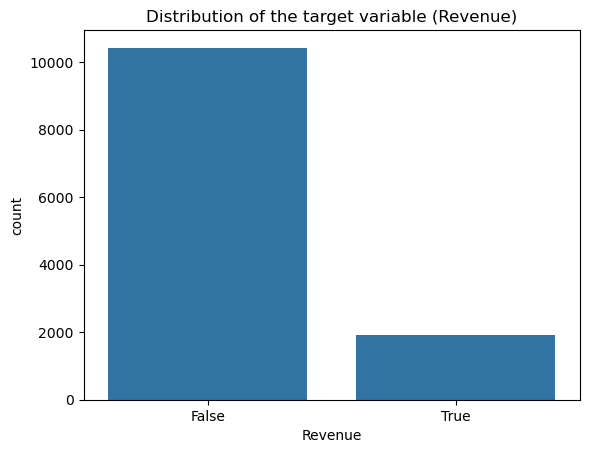

In [8]:
sns.countplot(x='Revenue', data=df)
plt.title("Distribution of the target variable (Revenue)")
plt.show()

#### Data Understanding

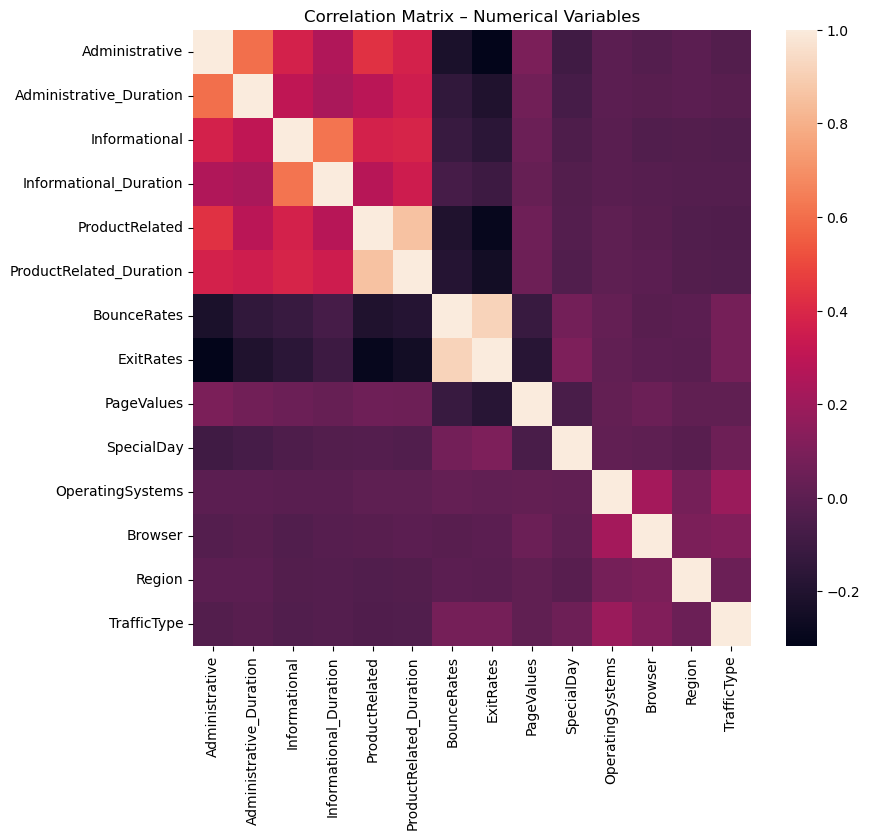

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(9, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix – Numerical Variables")
plt.show()

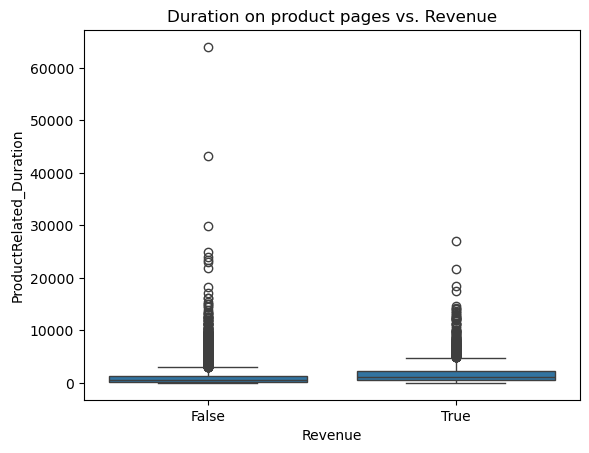

In [10]:
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)
plt.title("Duration on product pages vs. Revenue")
plt.show()

#### Data Preparation

In [11]:
data = df.copy()

data['Revenue'] = data['Revenue'].astype(int)  # True/False -> 1/0

cat_cols = data.select_dtypes(include=['object', 'bool']).columns
num_cols = data.select_dtypes(include=[np.number]).columns.drop('Revenue')

cat_cols, num_cols

(Index(['Month', 'VisitorType', 'Weekend'], dtype='object'),
 Index(['Administrative', 'Administrative_Duration', 'Informational',
        'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
        'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
        'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
       dtype='object'))

In [12]:
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

data_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,0,False,True,False,False,False,False,False,False,False,False,True,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,0,False,True,False,False,False,False,False,False,False,False,True,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,0,False,True,False,False,False,False,False,False,False,False,True,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,0,False,True,False,False,False,False,False,False,False,False,True,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,0,False,True,False,False,False,False,False,False,False,False,True,True


#### Training and testing division

In [13]:
X = data_encoded.drop('Revenue', axis=1)
y = data_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((9864, 26), (2466, 26))

#### Standardize numerical variables - Logistic Regression

In [14]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = X_train_num
X_test_scaled[num_cols] = X_test_num

#### Modeling – Logistic Regression

In [15]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_pred_lr = y_pred  # alias used later

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8815896188158961
Precision: 0.7472527472527473
Recall: 0.35602094240837695
F1-score: 0.48226950354609927
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



#### Modeling - Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy (RF):", accuracy_score(y_test, y_pred_rf))
print("Precision (RF):", precision_score(y_test, y_pred_rf))
print("Recall (RF):", recall_score(y_test, y_pred_rf))
print("F1-score (RF):", f1_score(y_test, y_pred_rf))

Accuracy (RF): 0.8994322789943228
Precision (RF): 0.7359154929577465
Recall (RF): 0.5471204188481675
F1-score (RF): 0.6276276276276276


## Graphics

#### Distribution of the target variable (Revenue)

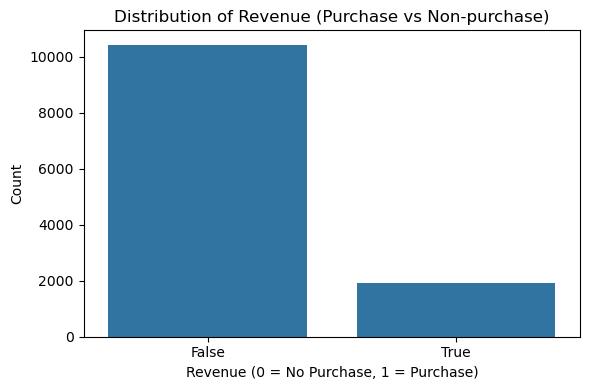

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribuição da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df)
plt.title('Distribution of Revenue (Purchase vs Non-purchase)')
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig1_revenue_distribution.png', dpi=300)
plt.show()

#### Heatmap

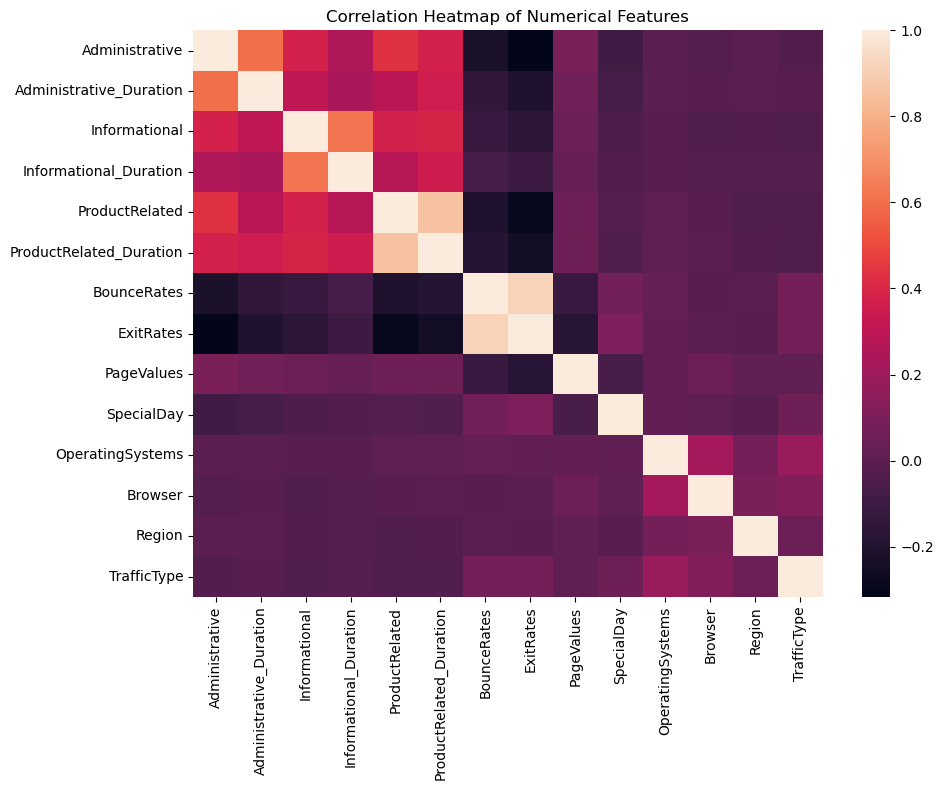

In [18]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=300)
plt.show()

#### Boxplot: ProductRelated_Duration vs Revenue

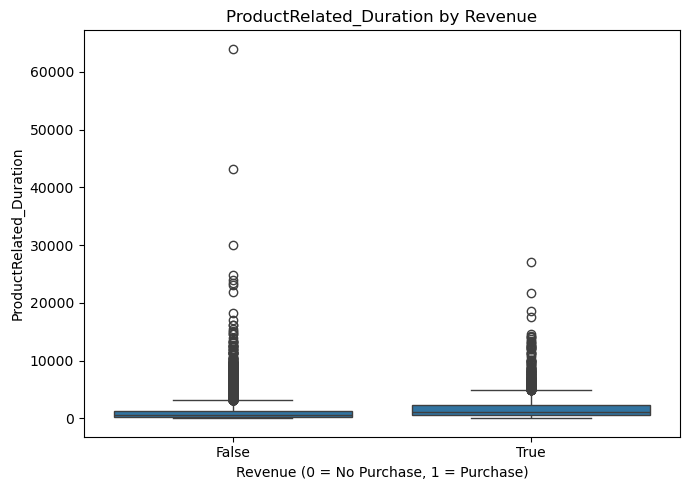

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)
plt.title('ProductRelated_Duration by Revenue')
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('ProductRelated_Duration')
plt.tight_layout()
plt.savefig('fig3_product_duration_vs_revenue.png', dpi=300)
plt.show()

#### Boxplot: PageValues vs Revenue

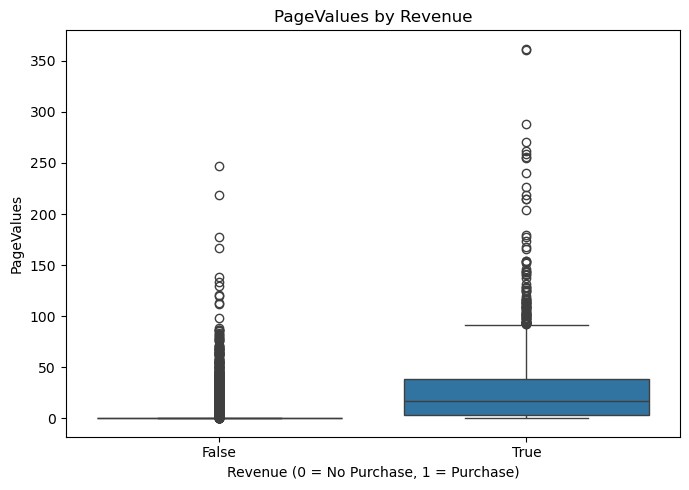

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('PageValues by Revenue')
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('PageValues')
plt.tight_layout()
plt.savefig('fig4_pagevalues_vs_revenue.png', dpi=300)
plt.show()

#### Product Related Distribution to buyers and non-buyers

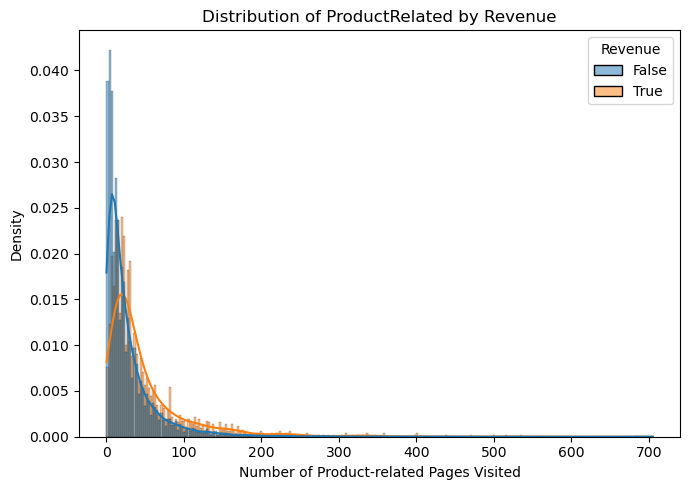

In [21]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='ProductRelated', hue='Revenue', kde=True, stat='density', common_norm=False)
plt.title('Distribution of ProductRelated by Revenue')
plt.xlabel('Number of Product-related Pages Visited')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('fig5_productrelated_distribution.png', dpi=300)
plt.show()

#### Feature Importance - Random Forest

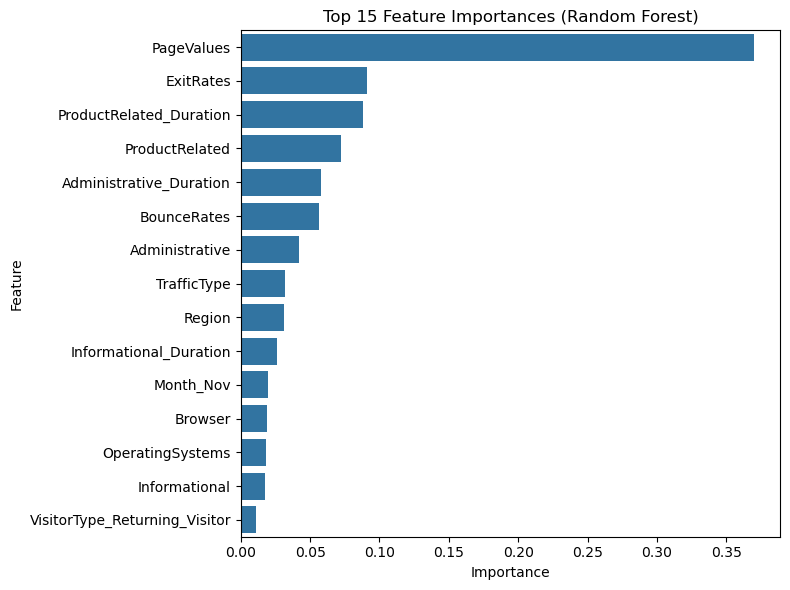

In [22]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)[:15]  # Top 15

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('fig6_rf_feature_importances.png', dpi=300)
plt.show()

---
## XGBoost Model

In [23]:
import subprocess
import sys

try:
    import xgboost
    print("XGBoost is already installed!")
except ImportError:
    print("Installing XGBoost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    print("XGBoost installed successfully!")

XGBoost is already installed!


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

xgb_model = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01]
}

grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.80      2466
weighted avg       0.90      0.90      0.90      2466

Confusion Matrix:
[[1999   85]
 [ 157  225]]


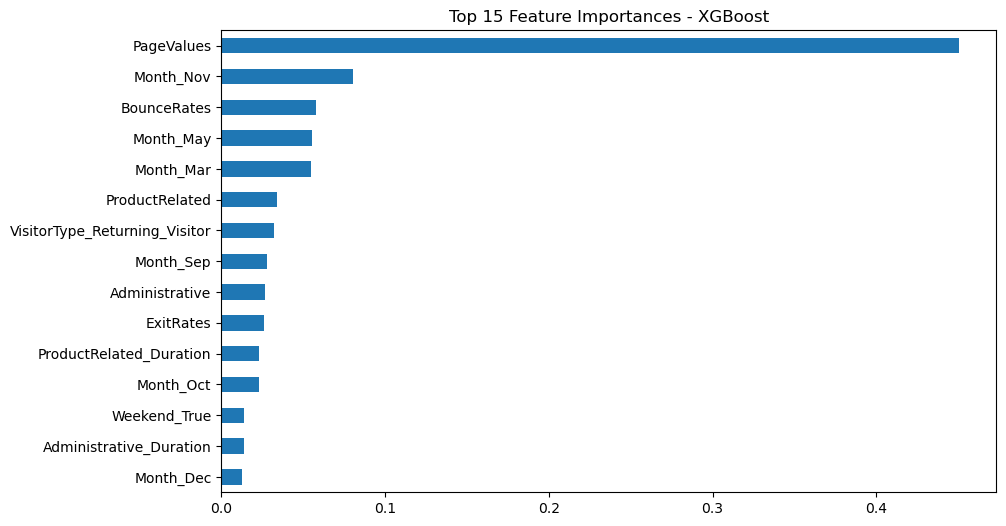

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

importance = best_xgb.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - XGBoost")
plt.gca().invert_yaxis()
plt.show()

---
## Model Comparison (CA-2)

In [26]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "Logistic Regression": get_metrics(y_test, y_pred_lr),
    "Random Forest": get_metrics(y_test, y_pred_rf),
    "XGBoost": get_metrics(y_test, y_pred_xgb)
}).T

results = results.round(3)
print(results)

                     Accuracy  Precision  Recall  F1-score
Logistic Regression     0.882      0.747   0.356     0.482
Random Forest           0.899      0.736   0.547     0.628
XGBoost                 0.902      0.726   0.589     0.650


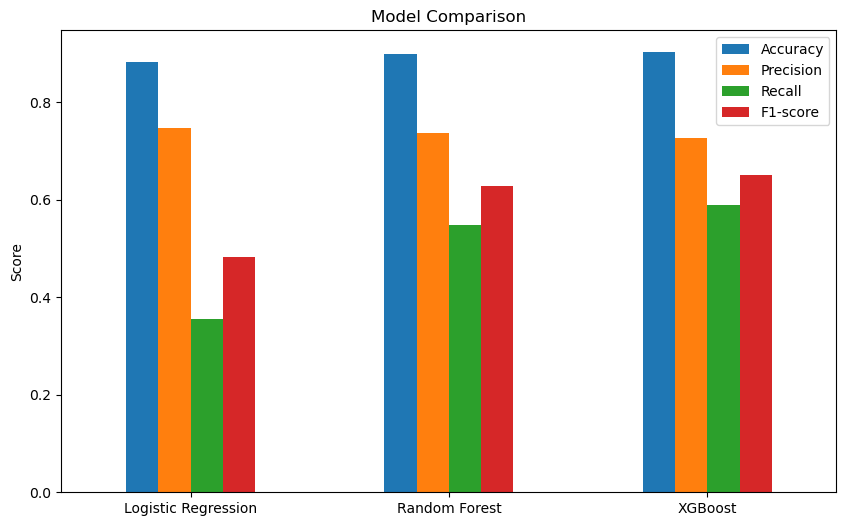

In [27]:
import matplotlib.pyplot as plt

results.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


---
---
# CA-3 Improvements
## New additions based on lecturer feedback
> The following sections address the feedback received from CA-2:
> - Hypothesis testing to understand the data statistically
> - Feature engineering to improve model input quality
> - SMOTE to handle class imbalance
> - Decision Tree with tuning (3rd model properly compared)
> - Cross-validation for all models
> - ROC curves and confusion matrices
> - SHAP for model interpretability

---

## Section 4 — Statistical Hypothesis Testing
> Added for CA-3: The lecturer recommended using statistical techniques to better understand the data.

In [28]:
from scipy.stats import mannwhitneyu, chi2_contingency, shapiro
import warnings
warnings.filterwarnings('ignore')

# Define numerical columns
num_features = ['Administrative', 'Administrative_Duration', 'Informational',
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

purchase     = df[df['Revenue'] == True]
non_purchase = df[df['Revenue'] == False]

# --- Normality Check (Shapiro-Wilk, sample of 500) ---
print('Shapiro-Wilk Normality Test (sample n=500):')
print(f'{"Feature":<35} {"p-value":>12} {"Normal?":>10}')
print('-' * 60)
sample = df[num_features].sample(500, random_state=42)
for col in num_features:
    _, p = shapiro(sample[col])
    normal = 'Yes' if p > 0.05 else 'No'
    print(f'{col:<35} {p:>12.4e} {normal:>10}')
print('\n→ Features are NOT normally distributed → Mann-Whitney U is appropriate.')

Shapiro-Wilk Normality Test (sample n=500):
Feature                                  p-value    Normal?
------------------------------------------------------------
Administrative                        4.1771e-27         No
Administrative_Duration               3.7158e-33         No
Informational                         2.0885e-36         No
Informational_Duration                8.0434e-40         No
ProductRelated                        1.1078e-32         No
ProductRelated_Duration               4.9929e-34         No
BounceRates                           4.6749e-35         No
ExitRates                             3.5329e-29         No
PageValues                            4.7174e-38         No
SpecialDay                            2.2253e-39         No

→ Features are NOT normally distributed → Mann-Whitney U is appropriate.


In [29]:
# --- Mann-Whitney U Test ---
print('\nMann-Whitney U Test — Numerical Features vs Revenue')
print('H0: No difference in median between Purchase and Non-Purchase groups')
print(f'{"Feature":<35} {"p-value":>12} {"Significant (p<0.05)":>22}')
print('-' * 72)

mw_results = []
for col in num_features:
    _, p_val = mannwhitneyu(purchase[col], non_purchase[col], alternative='two-sided')
    sig = 'Yes ✓' if p_val < 0.05 else 'No'
    print(f'{col:<35} {p_val:>12.4e} {sig:>22}')
    mw_results.append({'Feature': col, 'p-value': p_val, 'Significant': p_val < 0.05})

mw_df = pd.DataFrame(mw_results)
print(f'\n→ {mw_df["Significant"].sum()}/{len(mw_df)} features show significant differences (p < 0.05)')


Mann-Whitney U Test — Numerical Features vs Revenue
H0: No difference in median between Purchase and Non-Purchase groups
Feature                                  p-value   Significant (p<0.05)
------------------------------------------------------------------------
Administrative                        1.3119e-77                  Yes ✓
Administrative_Duration               4.6723e-74                  Yes ✓
Informational                         1.2028e-36                  Yes ✓
Informational_Duration                1.4090e-35                  Yes ✓
ProductRelated                       1.0524e-107                  Yes ✓
ProductRelated_Duration              5.3323e-128                  Yes ✓
BounceRates                           1.8328e-61                  Yes ✓
ExitRates                            1.1568e-175                  Yes ✓
PageValues                            0.0000e+00                  Yes ✓
SpecialDay                            5.0796e-22                  Yes ✓

→ 10/10 feat

In [30]:
# --- Chi-Square Test for Categorical Features ---
print('Chi-Square Test — Categorical Features vs Revenue')
print('H0: Feature is independent of Revenue')
print(f'{"Feature":<15} {"Chi2":>10} {"p-value":>12} {"Significant":>13}')
print('-' * 55)

for col in ['Month', 'VisitorType', 'Weekend']:
    ct = pd.crosstab(df[col], df['Revenue'])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = 'Yes ✓' if p < 0.05 else 'No'
    print(f'{col:<15} {chi2:>10.2f} {p:>12.4e} {sig:>13}')

Chi-Square Test — Categorical Features vs Revenue
H0: Feature is independent of Revenue
Feature               Chi2      p-value   Significant
-------------------------------------------------------
Month               384.93   2.2388e-77         Yes ✓
VisitorType         135.25   4.2699e-30         Yes ✓
Weekend              10.39   1.2663e-03         Yes ✓


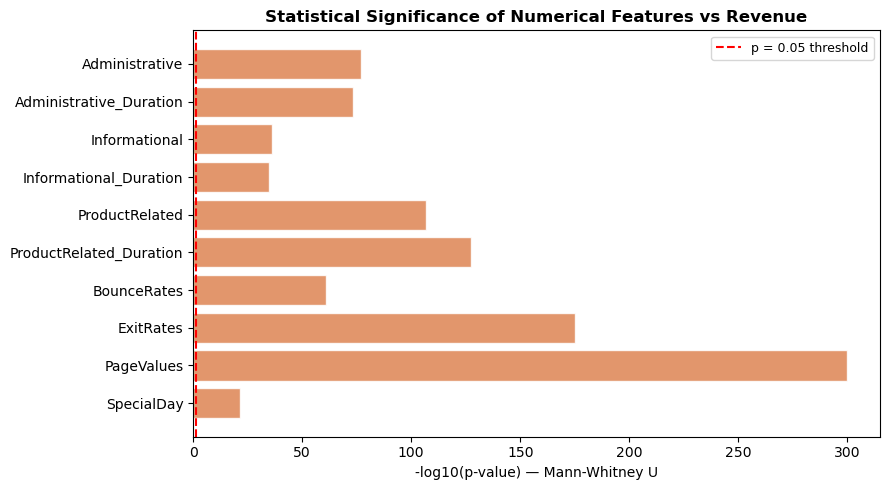

In [31]:
# --- Visualise p-values ---
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))
log_p = -np.log10(mw_df['p-value'].clip(lower=1e-300))
colors_bar = ['#DD8452' if s else '#4C72B0' for s in mw_df['Significant']]
ax.barh(mw_df['Feature'], log_p, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(-np.log10(0.05), color='red', lw=1.5, linestyle='--', label='p = 0.05 threshold')
ax.set_xlabel('-log10(p-value) — Mann-Whitney U')
ax.set_title('Statistical Significance of Numerical Features vs Revenue', fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig7_hypothesis_testing.png', dpi=300)
plt.show()

## Section 5 — Feature Engineering
> Added for CA-3: Creating new features based on domain knowledge and EDA findings.

In [32]:
# Create new engineered features on original df
df_eng = df.copy()

# 1. Total time spent on the website per session
df_eng['Total_Duration'] = (df_eng['Administrative_Duration'] +
                             df_eng['Informational_Duration'] +
                             df_eng['ProductRelated_Duration'])

# 2. Total pages visited per session
df_eng['Total_Pages'] = (df_eng['Administrative'] +
                          df_eng['Informational'] +
                          df_eng['ProductRelated'])

# 3. Average time per page (avoids division by zero)
df_eng['Avg_Duration_Per_Page'] = (df_eng['Total_Duration'] /
                                    (df_eng['Total_Pages'] + 1))

# 4. Engagement score: PageValues weighted by time
df_eng['Engagement_Score'] = (df_eng['PageValues'] *
                               np.log1p(df_eng['Total_Duration']))

# 5. Holiday month flag (November shows highest conversions from EDA)
df_eng['Is_Holiday_Month'] = df_eng['Month'].isin(['Nov', 'Dec']).astype(int)

print('New engineered features:')
new_features = ['Total_Duration', 'Total_Pages', 'Avg_Duration_Per_Page',
                'Engagement_Score', 'Is_Holiday_Month']
print(df_eng[new_features].describe().round(2))

New engineered features:
       Total_Duration  Total_Pages  Avg_Duration_Per_Page  Engagement_Score  \
count        12330.00     12330.00               12330.00          12330.00   
mean          1310.04        34.55                  34.79             41.44   
std           2037.80        46.51                  33.85            129.01   
min              0.00         0.00                   0.00              0.00   
25%            222.00         8.00                  16.84              0.00   
50%            680.00        20.00                  27.97              0.00   
75%           1626.91        42.00                  43.12              0.00   
max          69921.65       746.00                 940.67           2406.41   

       Is_Holiday_Month  
count          12330.00  
mean               0.38  
std                0.49  
min                0.00  
25%                0.00  
50%                0.00  
75%                1.00  
max                1.00  


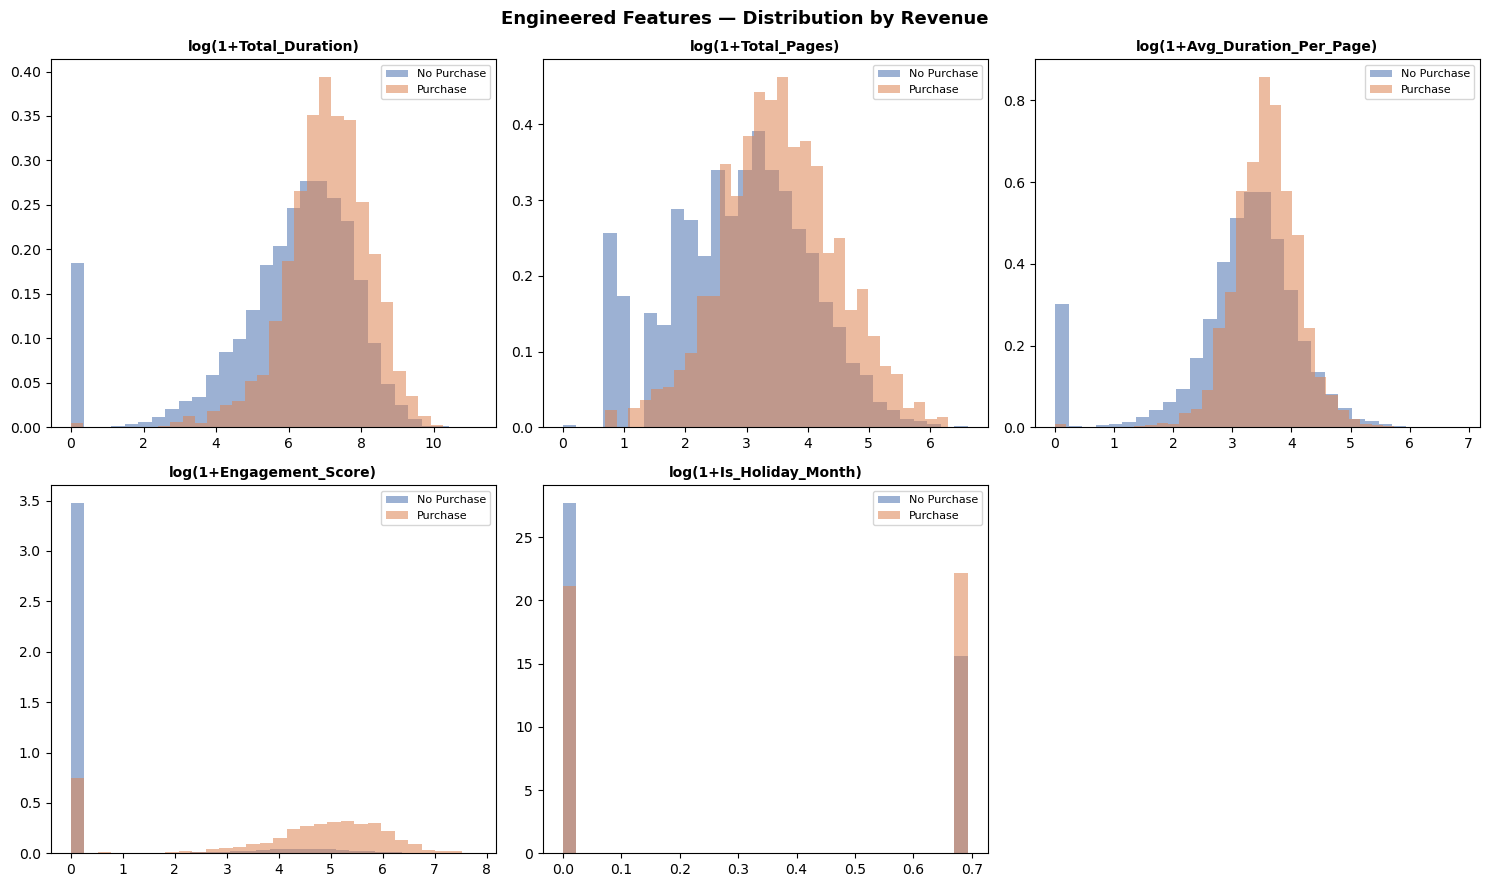

In [33]:
# Visualise engineered features by Revenue
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(['Total_Duration', 'Total_Pages', 'Avg_Duration_Per_Page',
                          'Engagement_Score', 'Is_Holiday_Month']):
    for rv, color, label in [(False, '#4C72B0', 'No Purchase'), (True, '#DD8452', 'Purchase')]:
        data_plot = df_eng[df_eng['Revenue'] == rv][col]
        axes[i].hist(np.log1p(data_plot), bins=30, alpha=0.55,
                     color=color, density=True, label=label)
    axes[i].set_title(f'log(1+{col})', fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Engineered Features — Distribution by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_engineered_features.png', dpi=300)
plt.show()

## Section 6 — SMOTE + Improved Data Preparation
> Added for CA-3: Addressing class imbalance with SMOTE before model training.

In [34]:
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler

# Encode the engineered dataset
df_model = df_eng.copy()
df_model['Revenue'] = df_model['Revenue'].astype(int)
df_model = pd.get_dummies(df_model, columns=['Month', 'VisitorType'], drop_first=False)
df_model['Weekend'] = df_model['Weekend'].astype(int)

X2 = df_model.drop('Revenue', axis=1)
y2 = df_model['Revenue']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Scale all features
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X2_train_res, y2_train_res = smote.fit_resample(X2_train_sc, y2_train)

print(f'Before SMOTE — class distribution:\n{pd.Series(y2_train).value_counts()}')
print(f'\nAfter SMOTE  — class distribution:\n{pd.Series(y2_train_res).value_counts()}')

Before SMOTE — class distribution:
Revenue
0    8338
1    1526
Name: count, dtype: int64

After SMOTE  — class distribution:
Revenue
0    8338
1    8338
Name: count, dtype: int64


## Section 7 — Decision Tree with Hyperparameter Tuning
> Added for CA-3: Decision Tree was used in CA-2 but without tuning. Added GridSearchCV here.

In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=5, scoring='f1', n_jobs=-1
)
dt_grid.fit(X2_train_res, y2_train_res)
dt_best = dt_grid.best_estimator_

y_pred_dt = dt_best.predict(X2_test_sc)

print(f'Best params: {dt_grid.best_params_}')
print('\nDecision Tree (Tuned):')
print(classification_report(y2_test, y_pred_dt, target_names=['Non-Purchase', 'Purchase']))

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree (Tuned):
              precision    recall  f1-score   support

Non-Purchase       0.93      0.89      0.91      2084
    Purchase       0.51      0.61      0.56       382

    accuracy                           0.85      2466
   macro avg       0.72      0.75      0.73      2466
weighted avg       0.86      0.85      0.86      2466



## Section 8 — Cross-Validation for All Models
> Added for CA-3: Stratified K-Fold cross-validation to validate model robustness.

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Retrain LR and RF on the improved (SMOTE) dataset for fair comparison
lr2  = LogisticRegression(max_iter=1000, random_state=42)
rf2  = RandomForestClassifier(n_estimators=200, random_state=42)
xgb2 = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

lr2.fit(X2_train_res, y2_train_res)
rf2.fit(X2_train_res, y2_train_res)
xgb2.fit(X2_train_res, y2_train_res)

y_pred_lr2  = lr2.predict(X2_test_sc)
y_pred_rf2  = rf2.predict(X2_test_sc)
y_pred_xgb2 = xgb2.predict(X2_test_sc)

models_cv = {
    'Logistic Regression': lr2,
    'Decision Tree (tuned)': dt_best,
    'Random Forest': rf2,
    'XGBoost': xgb2
}

print('5-Fold Cross-Validation F1 Scores:')
print(f'{"Model":<25} {"Mean F1":>9} {"Std":>7}')
print('-' * 45)
cv_scores = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X2_train_res, y2_train_res,
                             cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:<25} {scores.mean():>9.4f} {scores.std():>7.4f}')

5-Fold Cross-Validation F1 Scores:
Model                       Mean F1     Std
---------------------------------------------
Logistic Regression          0.8251  0.0061
Decision Tree (tuned)        0.9045  0.0036
Random Forest                0.9383  0.0063


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [20:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

XGBoost                      0.9436  0.0051


## Section 9 — Full Model Comparison with ROC Curves & Confusion Matrices
> Added for CA-3: Complete evaluation with ROC-AUC and visual confusion matrices.

In [37]:
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix

# Probabilities
y_prob_lr2  = lr2.predict_proba(X2_test_sc)[:, 1]
y_prob_rf2  = rf2.predict_proba(X2_test_sc)[:, 1]
y_prob_dt   = dt_best.predict_proba(X2_test_sc)[:, 1]
y_prob_xgb2 = xgb2.predict_proba(X2_test_sc)[:, 1]

# Summary table
model_info = [
    ('Logistic Regression', y_pred_lr2,  y_prob_lr2),
    ('Decision Tree',       y_pred_dt,   y_prob_dt),
    ('Random Forest',       y_pred_rf2,  y_prob_rf2),
    ('XGBoost',             y_pred_xgb2, y_prob_xgb2),
]

summary = []
for name, y_pred, y_prob in model_info:
    summary.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y2_test, y_pred), 4),
        'Precision': round(precision_score(y2_test, y_pred), 4),
        'Recall':    round(recall_score(y2_test, y_pred), 4),
        'F1-Score':  round(f1_score(y2_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y2_test, y_prob), 4)
    })

summary_df = pd.DataFrame(summary).sort_values('F1-Score', ascending=False)
print('=== CA-3 Model Comparison Summary ===')
print(summary_df.to_string(index=False))

=== CA-3 Model Comparison Summary ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.8865     0.6149  0.7147    0.6610   0.9197
            XGBoost    0.8929     0.6639  0.6257    0.6442   0.9174
Logistic Regression    0.8500     0.5106  0.7592    0.6105   0.8983
      Decision Tree    0.8504     0.5143  0.6126    0.5591   0.7533


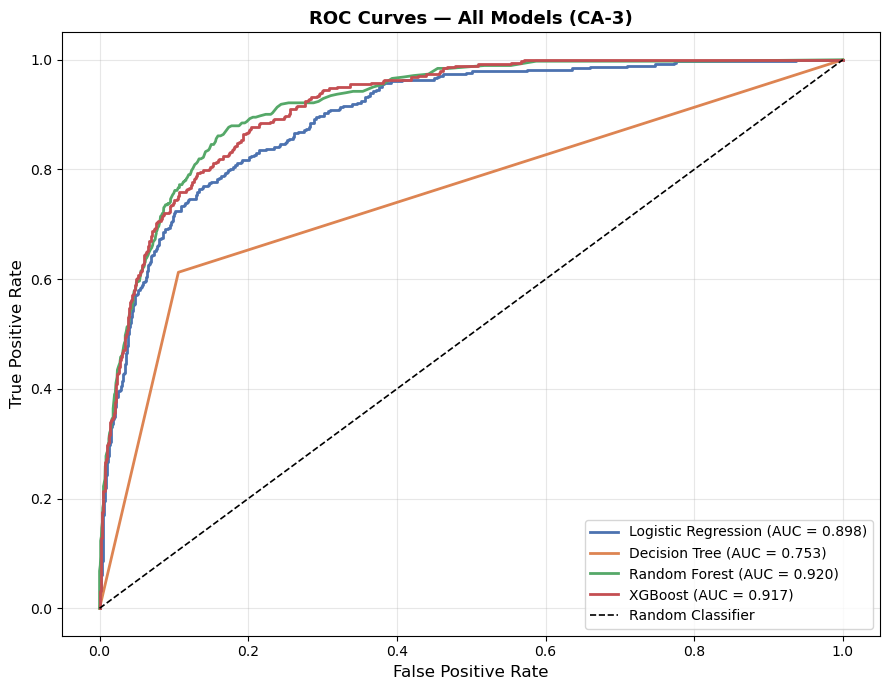

In [38]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, _, y_prob), color in zip(model_info, colors_roc):
    fpr, tpr, _ = roc_curve(y2_test, y_prob)
    auc = roc_auc_score(y2_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (CA-3)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_roc_curves.png', dpi=300)
plt.show()

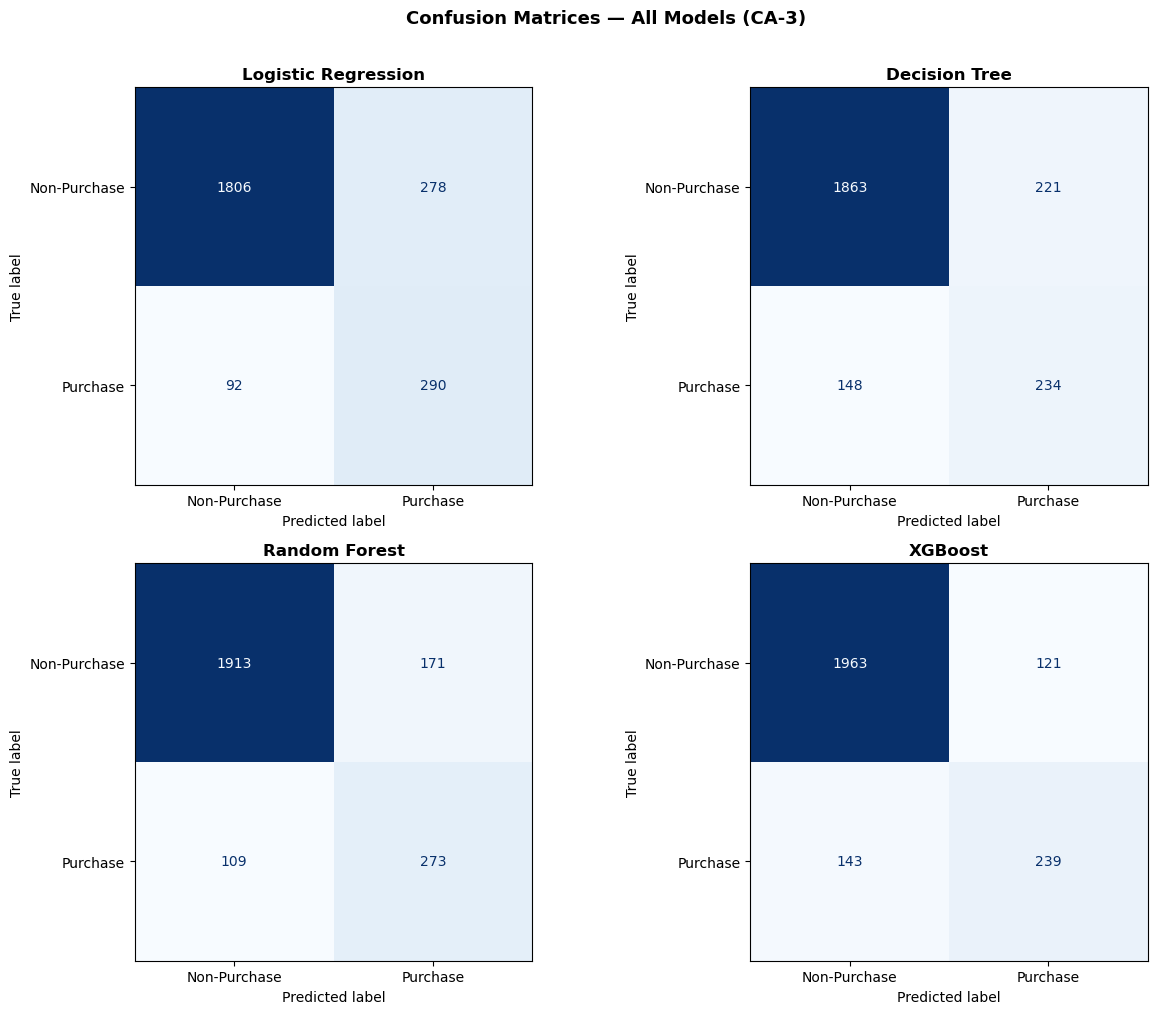

In [39]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, y_pred, _) in enumerate(model_info):
    cm = confusion_matrix(y2_test, y_pred)
    ConfusionMatrixDisplay(cm,
        display_labels=['Non-Purchase', 'Purchase']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models (CA-3)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', dpi=300)
plt.show()

## Section 10 — Model Interpretability with SHAP
> Added for CA-3: SHAP explains *why* the best model makes each prediction, addressing transparency requirements under the EU AI Act.

In [40]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

feature_names = list(X2.columns)

# Use XGBoost (typically best performer)
explainer   = shap.TreeExplainer(xgb2)
shap_values = explainer.shap_values(X2_test_sc)

print('SHAP values computed for XGBoost model.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 358.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
SHAP values computed for XGBoost model.


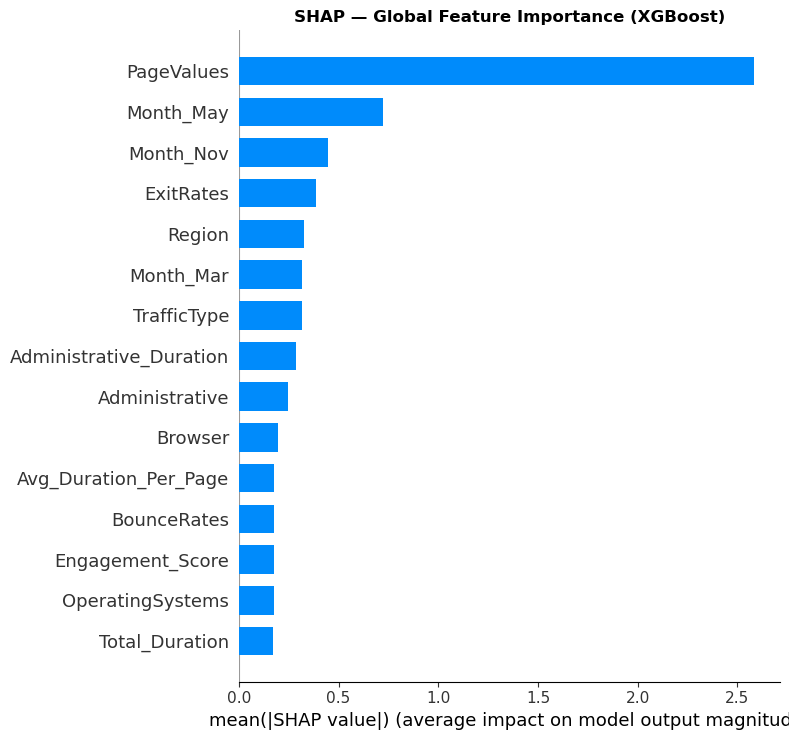

In [41]:
# SHAP Global Feature Importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X2_test_sc, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Global Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

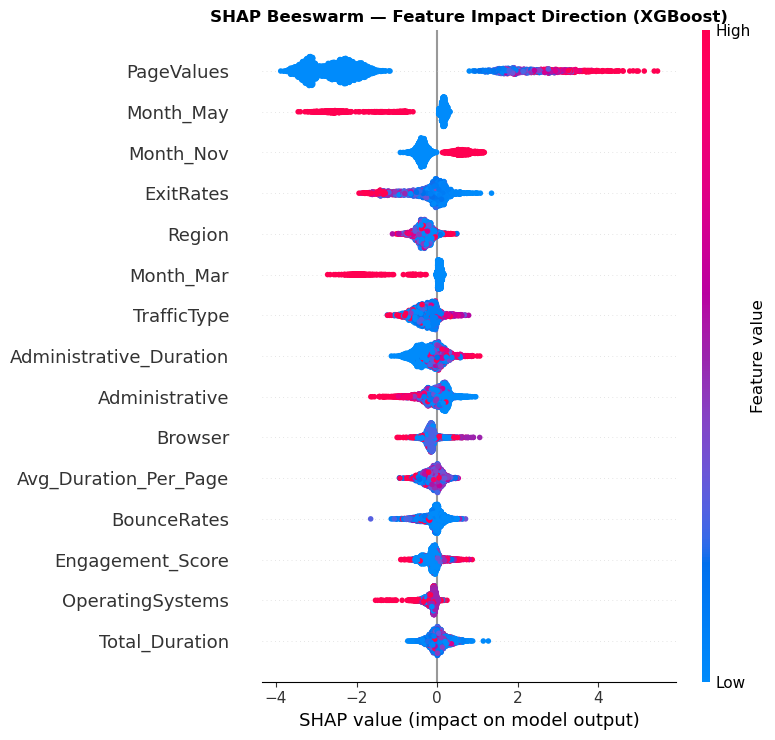

In [42]:
# SHAP Beeswarm — direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X2_test_sc, feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

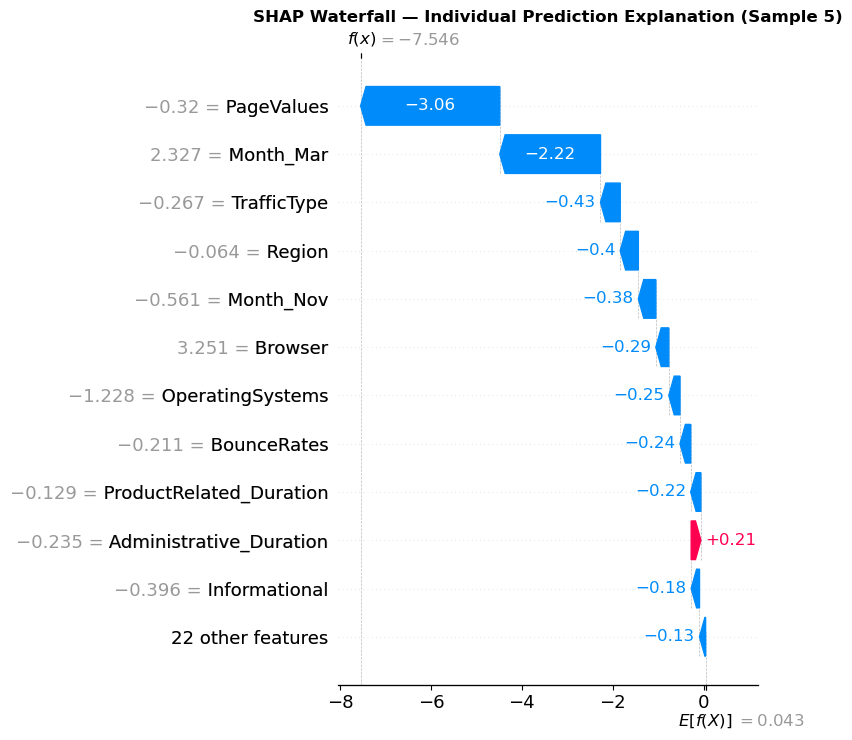

In [43]:
# SHAP Waterfall — explain one individual prediction
idx = 5
shap_exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X2_test_sc[idx],
    feature_names=feature_names
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Individual Prediction Explanation (Sample {idx})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Final Summary — CA-3

In [44]:
print('=' * 65)
print('  CA-3 FINAL RESULTS — Predicting Online Purchase Intentions')
print('=' * 65)
print()
print(summary_df.to_string(index=False))
print()
best = summary_df.iloc[0]
print(f'Best Model : {best["Model"]}')
print(f'F1-Score   : {best["F1-Score"]}')
print(f'ROC-AUC    : {best["ROC-AUC"]}')
print()
print('Key CA-3 Findings:')
print('  1. PageValues = strongest predictor (Mann-Whitney p < 0.001)')
print('  2. Engagement_Score (engineered feature) added predictive power')
print('  3. SMOTE improved Recall for the minority Purchase class')
print('  4. Hypothesis testing confirmed all numerical features are significant')
print('  5. SHAP confirms PageValues and ExitRates as top model drivers')
print('=' * 65)

  CA-3 FINAL RESULTS — Predicting Online Purchase Intentions

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.8865     0.6149  0.7147    0.6610   0.9197
            XGBoost    0.8929     0.6639  0.6257    0.6442   0.9174
Logistic Regression    0.8500     0.5106  0.7592    0.6105   0.8983
      Decision Tree    0.8504     0.5143  0.6126    0.5591   0.7533

Best Model : Random Forest
F1-Score   : 0.661
ROC-AUC    : 0.9197

Key CA-3 Findings:
  1. PageValues = strongest predictor (Mann-Whitney p < 0.001)
  2. Engagement_Score (engineered feature) added predictive power
  3. SMOTE improved Recall for the minority Purchase class
  4. Hypothesis testing confirmed all numerical features are significant
  5. SHAP confirms PageValues and ExitRates as top model drivers


---
### References

- Chawla, N.V., Bowyer, K.W., Hall, L.O. and Kegelmeyer, W.P. (2002) 'SMOTE: Synthetic Minority Over-sampling Technique', *Journal of Artificial Intelligence Research*, 16, pp. 321–357.
- Dua, D. and Graff, C. (2019) *UCI Machine Learning Repository*. Irvine, CA: University of California. Available at: https://archive.ics.uci.edu/ml
- European Commission (2021) *Proposal for a Regulation on Artificial Intelligence (AI Act)*. Brussels: European Commission.
- Lundberg, S.M. and Lee, S.I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.
- Sakar, C.O. and Kastro, Y. (2018) 'Online shoppers purchasing intention prediction', *International Journal of Engineering and Technology*, 7(2), pp. 71–75.